### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [20]:
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
df = df.drop([df.columns[0], df.columns[-1]], axis=1)

**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

We first set the default figsize to 7.10*6.70. The n_vars is the number of columns. We initialize our plots using subplots, which gives us the fig and ax objects, where fig is the figure and ax holds the plot data. We then ajust the size of the margins of the figure. Then we get, for every combination of variables, the axis object at the intersection. We get the name of the variables, and create a scatter plot in the axis object. If the variables are the same, i.e. along the diagonal, text with the variable name is simply put there instead.

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

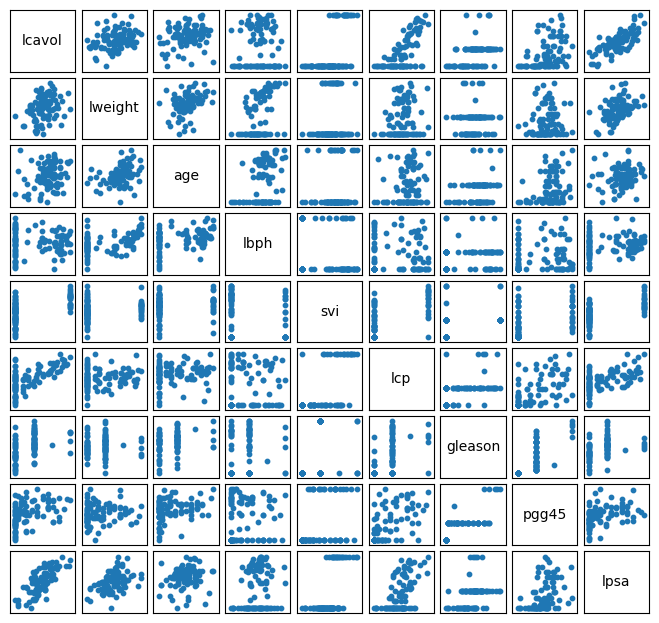

In [21]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

lcp and lpsa seem the most correlated with lcavol from the figure.
Most predictors seem to be floats, as they have datapoints spread across the x-axis. The exceptions are svi and gleason, where svi has a binary value and gleason has four possible values.

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

In [22]:
import numpy as np

def corr(u, v):
    n = len(u)
    cov = n*np.sum(np.multiply(u, v)) - np.sum(u)*np.sum(v)
    def sigma(x):
        return np.sqrt(n*np.sum(np.multiply(x, x)) - np.sum(x)**2)
    return cov / (sigma(u)*sigma(v))

print(df.corr())
corr_df = pd.DataFrame(index=df.columns, columns=df.columns)
for i in range(df.shape[1]):
    for j in range(df.shape[1]):
        i_name = df.columns[i]
        j_name = df.columns[j]
        # print(f"Correlation {i_name} to {j_name} is {corr(df[i_name], df[j_name])}")
        corr_df.at[i_name, j_name] = corr(df[i_name], df[j_name])

print(corr_df)

           lcavol   lweight       age      lbph       svi       lcp   gleason  \
lcavol   1.000000  0.280521  0.225000  0.027350  0.538845  0.675310  0.432417   
lweight  0.280521  1.000000  0.347969  0.442264  0.155385  0.164537  0.056882   
age      0.225000  0.347969  1.000000  0.350186  0.117658  0.127668  0.268892   
lbph     0.027350  0.442264  0.350186  1.000000 -0.085843 -0.006999  0.077820   
svi      0.538845  0.155385  0.117658 -0.085843  1.000000  0.673111  0.320412   
lcp      0.675310  0.164537  0.127668 -0.006999  0.673111  1.000000  0.514830   
gleason  0.432417  0.056882  0.268892  0.077820  0.320412  0.514830  1.000000   
pgg45    0.433652  0.107354  0.276112  0.078460  0.457648  0.631528  0.751905   
lpsa     0.734460  0.433319  0.169593  0.179809  0.566218  0.548813  0.368987   

            pgg45      lpsa  
lcavol   0.433652  0.734460  
lweight  0.107354  0.433319  
age      0.276112  0.169593  
lbph     0.078460  0.179809  
svi      0.457648  0.566218  
lcp      

The correlations are the same, except that `df.corr()` shows the same number of zeros for all datapoints, whereas my `corr()` function removes unnecessary zeros, which could be added to `corr()`.

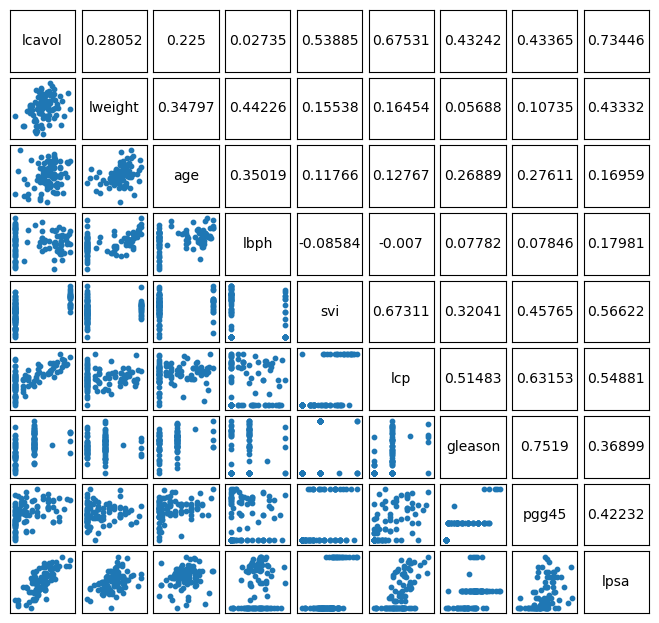

In [ ]:
# make a pairplot vith the correlation values in the upper triangle
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i < j:
                correlation = round(corr(df[i_name], df[j_name]), 5)
                axij.text(0.5, 0.5, correlation, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)
            elif i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

$\text{lcavol} = \beta_0 + \beta_{svi} \text{svi} + \beta_{gleason} \text{gleason} + \beta_{lweight} \text{lweight} + \beta_{age} \text{age} + \beta_{lbph} \text{lbph} + \beta_{lcp} \text{lcp} + \beta_{pgg45} \text{pgg45} + \beta_{lpsa} \text{lpsa} + \epsilon$

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`? The default type, Bool, conflicts with the type of the rest of the data.
- Why did we drop two columns after the encoding? The lowest value for each predictor can be represented by having all other predictors be 0 and can thus be skipped, which reduces the risk of colinearity.
- Why did we add a column of ones to the dataframe? The intercept is the $\beta_0$, which doesn't depend on the data which is modeled with a dummy variable that is always one.

In [24]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']


**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [25]:
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        08:47:14   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- The coefficient for svi tells us that having svi_1 makes us predict a lower lcavol as opposed to svi_0. Similarily, the coefficients for gleason are the coefficients for the categorical predictors gleason_[7-9].
- The categorical predictors would become continuous, forcing the regression to fit linear coefficients for the value of the categories. For instance, having gleason_9 would give gleason=9, and \beta_{gleason} would be scaled accordingly. The difference would be especially visible for gleason, as the current relationship between the coefficients is not linear with respect to the value of gleason.
- lcp, lpsa, and gleason have the strongest impacts in the model, with age, lweight and pgg45 having the weakest impacts.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [26]:
results.conf_int()

,0,1
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


age is showing a weak but strictly positive effect. lcp and lpsa are showing stronger positive effects. pgg45 shows a weak negative effect. The other coefficients have their confidence intervals spanning both sides of 0.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [27]:
results.pvalues

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64

lpsa shows a promising confidence interval of 0.37 - 0.73. The p-value is low, 2.92*10^-8, which means the results are statistically significant. lpsa is an important predictor in the model.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [28]:
# Get the regression coefficients
beta_hat = np.linalg.solve(X.T @ X, X.T @ y)
print("parameters:")
print(beta_hat)

# Get the p values
residuals = y - X @ beta_hat
sigma_squared = np.sum(residuals**2) / (X.shape[0] - X.shape[1])
var_beta_hat = sigma_squared * np.linalg.inv(X.T @ X)
se_beta_hat = np.sqrt(np.diag(var_beta_hat))
t_stats = beta_hat / se_beta_hat
from scipy import stats
df = X.shape[0] - X.shape[1]
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df))

print("p values:")
print(p_values)

parameters:
[-0.0112462   0.02478241 -0.10419954  0.40275962 -0.00944383  0.5495731
 -0.22041936  0.31167619 -0.71058822  0.79013455 -1.40665404]
p values:
[9.57707489e-01 3.01499280e-02 7.69560879e-02 8.57785824e-06
 4.04774068e-02 2.93924065e-08 3.92271694e-01 1.51294991e-01
 3.51674448e-01 1.08731299e-01 1.11367559e-01]


**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

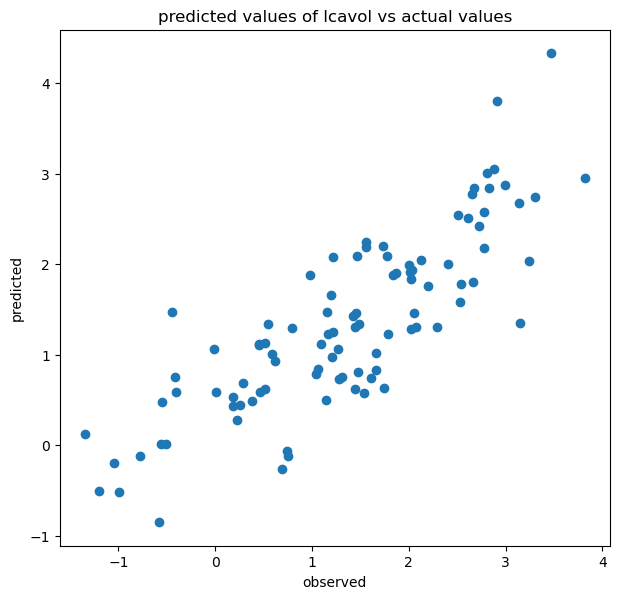

In [29]:
predicitions = results.get_prediction(X).predicted_mean
fig = plt.figure(figsize=(7.10, 6.70))
plt.scatter(y, predicitions)
plt.xlabel("observed")
plt.ylabel("predicted")
plt.title("predicted values of lcavol vs actual values")
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

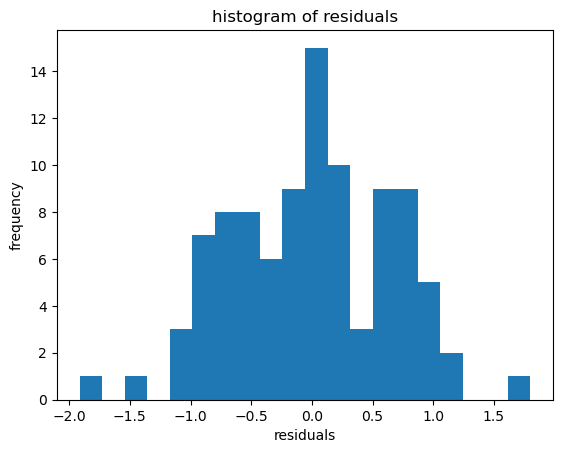

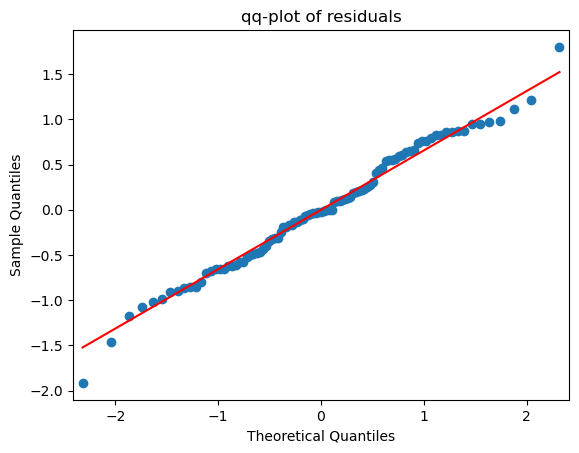

residual sum of squares: 41.81406860804535


In [30]:
# histogram of residuals
plt.hist(results.resid, bins=20)
plt.xlabel("residuals")
plt.ylabel("frequency")
plt.title("histogram of residuals")

# qq-plot of residuals
sm.qqplot(results.resid, line='s')
plt.title("qq-plot of residuals")
plt.show()

# residual sum of squares
rss = np.sum(results.resid**2)
print(f"residual sum of squares: {rss}")

The histogram of the residuals has roughly the bell-shaped form that you would expect from normally distributed residuals, and the sample quantiles follow the theoretical quantiles fairly well. This is strong evidence that the residuals are normally distributed. The RSS is 41.8.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [31]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        08:47:15   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
new_X = df_enc.drop(columns=['lcavol', "lpsa", "lcp"])

new_model = sm.OLS(y, new_X)
new_results = new_model.fit()
new_results.summary()
# results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        08:47:16   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight        0.5850      0.259      2.257      0.026       0.070       1.100
age            0.0073      0.015      0.497      0.621      -0.022       0.036
lbph          -0.0746      0.077     -0.967      0.336      -0.228       0.079
pgg45         -0.0004      0.006     -0.076      0.939      -0.012       0.011
svi_1          1.0246      0.271      3.774      0.000       0.485       1.564
gleason_7      0.8007      0.274      2.918      0.004       0.255       1.346
gleason_8      0.6869      0.960      0.715      0.476      -1.221       2.595
gleason_9      1.1726      0.644      1.820      0.072      -0.108       2.453
intercept     -1.9717      1.159     -1.701      0.092      -4.275       0.332
==============================================================================
Omnibus:                        0.297   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.862   Jarque-Bera (JB):                0.473
Skew:                          -0.013   Prob(JB):                        0.789
Kurtosis:                       2.659   Cond. No.                         882.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The only statistically significant parameters are now lweight, svi_1 and gleason_7. Interestingly, these were not statistically significant in the previous regression. On the other hand, age and pgg45 were signifantly significant in the first regression, but not in the one.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

In [33]:
import itertools
predictor_names = X.columns
k = 2
min_rss = float("inf")
best_combination = None
for combination in itertools.combinations(predictor_names, k):
    X_subset = X[list(combination) + ["intercept"]]
    model_subset = sm.OLS(y, X_subset)
    results_subset = model_subset.fit()
    rss_subset = np.sum(results_subset.resid**2)
    if rss_subset < min_rss:
        min_rss = rss_subset
        best_combination = combination

print(f"Best combination: {best_combination}, RSS: {min_rss}")


Best combination: ('lcp', 'lpsa'), RSS: 47.27809728978648


The combination lcp and lpsa gives the best RSS of 47.38

Best combination for k=0: (), RSS: 133.35903388922304
Best combination for k=1: ('lpsa',), RSS: 61.42090741678992
Best combination for k=2: ('lcp', 'lpsa'), RSS: 47.27809728978648
Best combination for k=3: ('age', 'lcp', 'lpsa'), RSS: 46.237825150928
Best combination for k=4: ('age', 'lbph', 'lcp', 'lpsa'), RSS: 44.878406032340415
Best combination for k=5: ('age', 'lbph', 'lcp', 'pgg45', 'lpsa'), RSS: 44.31133248731896
Best combination for k=6: ('age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_8'), RSS: 43.77602097098613
Best combination for k=7: ('age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_7', 'gleason_9'), RSS: 42.47364094908341
Best combination for k=8: ('age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_7', 'gleason_8', 'gleason_9'), RSS: 42.17393288847962


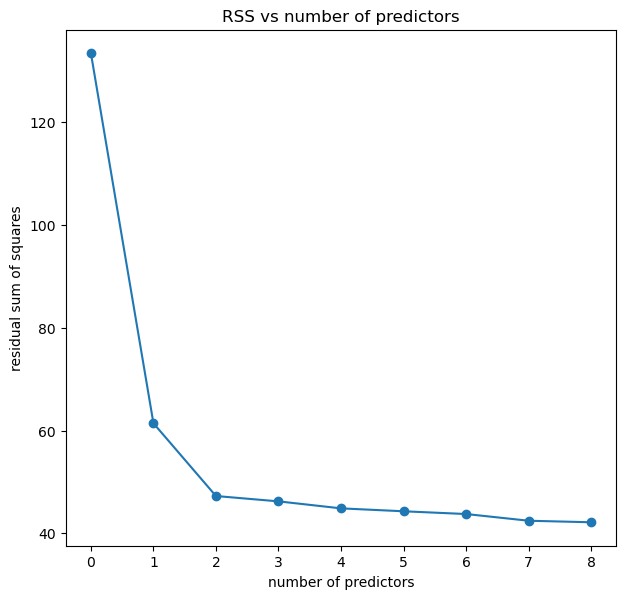

In [34]:
rss_values = []
best_combinations = []

for k in range(0, 9):
    min_rss = float("inf")
    best_combination = None
    for combination in itertools.combinations(predictor_names, k):
        X_subset = X[list(combination) + ["intercept"]]
        model_subset = sm.OLS(y, X_subset)
        results_subset = model_subset.fit()
        rss_subset = np.sum(results_subset.resid**2)
        if rss_subset < min_rss:
            min_rss = rss_subset
            best_combination = combination

    print(f"Best combination for k={k}: {best_combination}, RSS: {min_rss}")
    rss_values.append(min_rss)
    best_combinations.append(best_combination)

fig = plt.figure(figsize=(7.10, 6.70))
plt.plot(range(0, 9), rss_values, marker='o')
plt.xlabel("number of predictors")
plt.ylabel("residual sum of squares")
plt.title("RSS vs number of predictors")
plt.show()

TODO: förmodligen inte helt korrekt, kolla 4a

To avoid overfitting, a good strategy would be to select the lowest number of predictors where adding more predictors does not give a meaningful improvement. The RSS gives a measure of the training error, which makes it a good metric to know when to stop. As can be seen in this case, however, it is not sufficient to simply minimize the RSS, as that would mean adding the maximum number of predictors, but rather to stop at 5 or 7, where the improvement of adding more is low.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

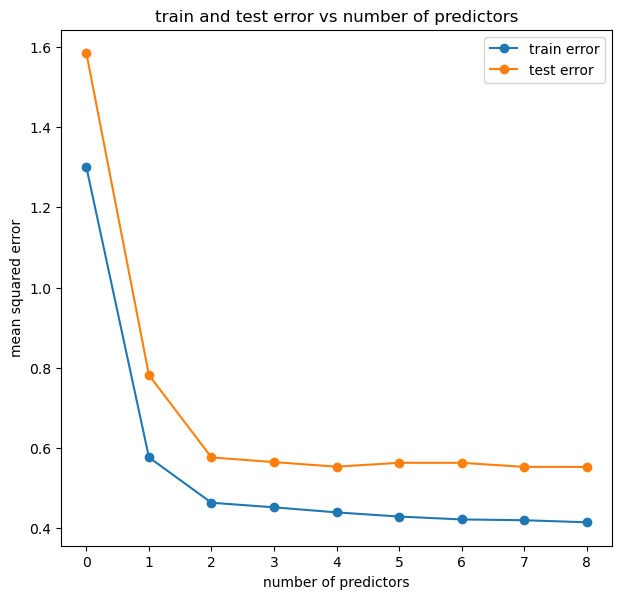

In [35]:
import sklearn
train_X, test_X, train_y, test_y = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

train_errors = []
test_errors = []

for k in range(0, 9):
    best_combination = best_combinations[k]
    train_X_subset = train_X[list(best_combination) + ["intercept"]]
    test_X_subset = test_X[list(best_combination) + ["intercept"]]
    model_subset = sm.OLS(train_y, train_X_subset)
    results_subset = model_subset.fit()

    test_predictions = results_subset.predict(test_X_subset)
    train_predictions = results_subset.predict(train_X_subset)

    mean_test_error = np.mean((test_predictions - test_y)**2)
    mean_train_error = np.mean((train_predictions - train_y)**2)

    train_errors.append(mean_train_error)
    test_errors.append(mean_test_error)

fig = plt.figure(figsize=(7.10, 6.70))
plt.plot(range(0, 9), train_errors, marker='o', label="train error")
plt.plot(range(0, 9), test_errors, marker='o', label="test error")
plt.xlabel("number of predictors")
plt.ylabel("mean squared error")
plt.title("train and test error vs number of predictors")
plt.legend()
plt.show()

In [36]:
best_k = 2
best_subset = best_combinations[best_k]
X_subset = X[list(best_subset) + ["intercept"]]
model_subset = sm.OLS(y, X_subset)
results_subset = model_subset.fit()
results_subset.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     85.57
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           6.81e-22
Time:                        08:47:20   Log-Likelihood:                -102.78
No. Observations:                  97   AIC:                             211.6
Df Residuals:                      94   BIC:                             219.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lcp            0.3284      0.062      5.303      0.000       0.205       0.451
lpsa           0.5316      0.075      7.087      0.000       0.383       0.681
intercept      0.0913      0.205      0.445      0.657      -0.316       0.499
==============================================================================
Omnibus:                        0.298   Durbin-Watson:                   2.374
Prob(Omnibus):                  0.861   Jarque-Bera (JB):                0.370
Skew:                           0.127   Prob(JB):                        0.831
Kurtosis:                       2.836   Cond. No.                         8.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.